In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df = pd.read_csv('/content/netflix_titles.csv')

In [ ]:
df.shape

(8807, 12)

In [ ]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [ ]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [56]:
df.duplicated().sum()

np.int64(0)

Step 1 — Load & Inspect the Data(Summary)

1. On analyzing the Netflix dataset, we can see that it contains 8,807 rows and 12 columns.

2. The dataset contains information about Netflix movies and TV shows which includes attributes such as show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in and description.

3. Most of the columns in the dataset are of object datatype, while only the release_year column is of numeric (int) datatype.

4. We can observe that some columns contain missing values. Among them, the director column has the highest number of missing values, with around 2,634 missing entries out of 8,807 records.

5. On further observation, no duplicate records were found in the dataset, which means all the entries in the dataset are unique.

In [57]:
print(df.isnull().sum()/len(df)* 100)

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


we are already see Null value, now we are see the Null value in percentage.Take this percentage value help and modifyed the next step

In [58]:
df.drop("director",axis = 1,inplace =  True)

Step 2- 1. Director Column Dropped.

1.The director column was dropped from the dataset because it contained 2,634 missing values out of 8,807 records, which is approximately 30% of the total data [(2634/8807) × 100 = 29.9% ≈ 30%].

2.The director names are generally unique for different movies and TV shows, therefore filling the missing values would not contribute meaningfully to the analysis.

3.The missing values also cannot be reasonably filled using mean or median since the column contains text data. Although mode can be used, the most frequent director would still represent only a small portion of the dataset and would not be suitable for replacing such a large number of missing values.
Therefore, dropping the column was considered the most appropriate decision.n



In [ ]:
df["cast"] = df["cast"].fillna("unknown")

Step 2- 2. Cast column.

1.The missing values in the cast column were replaced with "Unknown" because the column contained 825 missing values out of 8,807 records, which is approximately 9.4% of the dataset.

2.Dropping the entire column would not be beneficial as more than 90% of the records still contain useful cast information that can be used for further analysis.

3.Filling the missing values using mode was not considered appropriate because the most frequent cast combination would represent only a small portion of the dataset and would not accurately represent the missing entries.

4.Therefore, replacing the missing values with "Unknown" was considered a more suitable approach

In [ ]:
df['country'] = df['country'].fillna('Unknown')

Step 2-3. Country Column

1.The country column was handled using a methodology consistent with the cast column, given that it contains 831 missing entries across 8,807 total records, with the bulk of the data remaining available.

2.This column holds significant analytical value, particularly for examining how movies and TV shows on Netflix are distributed across different regions worldwide.

3.Removing the column entirely would sacrifice meaningful insights, whereas substituting missing values with arbitrary country names risks introducing false data and compromising the reliability of any analysis.

4.To strike a balance, the missing values were substituted with "Unknown," ensuring the dataset remains intact while transparently acknowledging where information could not be determined.

In [ ]:
df["rating"] = df['rating'].fillna(df['rating'].mode()[0])

Step 2-4. Rating Column

1. The rating column contains only 4 missing values, which makes dropping either the column or the affected rows unnecessary — instead, these gaps will be filled directly.

2. Several techniques exist for addressing missing values, including mean, median, mode, forward fill, and backward fill. Among these, mode proves to be the most appropriate choice for this column, as it replaces missing entries with the most frequently occurring rating.

3. Mean and median are ruled out as viable options since the rating column consists of object-type categorical data, making numerical calculations inapplicable.

4. Forward fill and backward fill are equally unsuitable, as both methods derive values from adjacent records, which bear no guaranteed relevance to the actual rating and could therefore introduce misleading results.

In [ ]:
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

Step 2-5. Duration Column

1. With only 3 missing values out of 8,807 records, eliminating the duration column entirely would be an unnecessary measure, as it continues to hold relevant information that can support further analysis.
Several approaches are available for addressing these missing values, including mode, forward fill, and backward fill.


2. Forward fill and backward fill were dismissed as unsuitable options, since both techniques assign values derived from neighboring records, which may bear no relation to the actual duration of a given title.


3. Mode was equally considered inappropriate, given that the duration column encompasses a wide range of values — spanning both movie runtimes and TV show season counts — meaning the most frequently occurring value would not necessarily be a reliable representation of the missing entries.


4.Consequently, the missing values were replaced with "Unknown," allowing the dataset to remain preserved while explicitly signaling that the relevant information was unavailable.

In [ ]:
df["date_added"] = df["date_added"].fillna("Unknown")

tep 2-6. Date Added Column
The date_added column carries 10 missing values, for which two potential approaches were considered.

Approach 1: Replacing the missing values with "Unknown". Techniques such as mode, forward fill, or backward fill risk inserting incorrect dates into the dataset, potentially undermining its consistency. Substituting the missing values with "Unknown" instead safeguards data integrity while making it explicitly clear that the information is not available.

Approach 2: Removing the 10 rows with missing values. These 10 records account for merely 0.11% of the entire dataset [(10/8807) × 100], meaning their removal would have a negligible effect on the overall analysis. That said, eliminating these rows also carries the risk of discarding useful information stored in the remaining columns.

Given these considerations, Approach 1 was ultimately chosen, with the missing values being replaced by "Unknown" to ensure all records are retained and the dataset maintains its overall consistency.

In [ ]:
df.isnull().sum()


,0
show_id,0
type,0
title,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


Step 2- Final Summary

As we can see, all the missing values have been handled properly while maintaining the data integrity and consistency of the dataset. Appropriate methods were selected for each column based on the type of data and the number of missing values. Therefore, the dataset is now clean and ready for further analysis and visualization.

step 3 - Exploratory Data Analysis


Q.2-Which countries have the highest number of Netflix titles?

In [ ]:
df.groupby("country")["title"].count().sort_values(ascending=False).head(10)

,title
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


Answer:- The United States have the highest Netflix titles with **2,818** titles followed by India having **972** titles and then the United Kingdom having **419** titles.


Q2.What is the most common content rating on Nteflix ?

In [ ]:
q2 = df['rating']. value_counts().head(5)
print(q2)

Ans: TV-MA is the most common rating with 3212 titles, meaning most Netflix content is made for mature audiences.

Q3. How many Movies vs TV Shows are on Netflix?

In [ ]:
q3 = df['type'].value_counts()
print(q3)

Ans: Netflix has 6131 Movies and 2666 TV Shows in total.

Q4: Which year had the most content released?

In [ ]:
q4 = df['release_year'].value_counts().head(5)
print(q4)

Ans: 2018 had the most content released with 1146 titles, followed by 2017 (1032) and 2019 (1030).

Q5. What percentage of content is Movies vs TV Shows?

In [ ]:
q5 = (df['type'].value_counts(normalize=True) * 100).round(2)
print(q5)

Ans: Netflix content is 69.69% Movies and 30.31% TV Shows, meaning movies make up nearly 7 out of every 10 titles.

step 4 - Visualizations (Minimum 6 Charts)

visualization 1 : Top 10 release_year by Number of Netflix Titles(Bar chart)

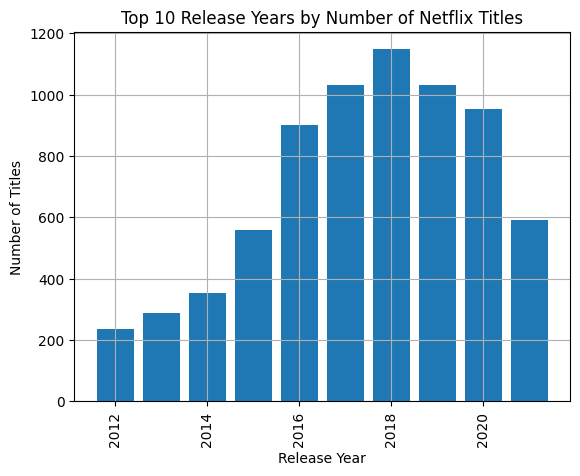

In [60]:
top10 = df["release_year"].value_counts().head(10)
plt.bar(top10.index, top10.values)
plt.xlabel("Release Year")
plt.xticks(rotation=90)
plt.grid()
plt.ylabel("Number of Titles")
plt.title("Top 10 Release Years by Number of Netflix Titles")
plt.show()

Visualization 2: Netflix Titles Released by cast(Line chart)

/tmp/ipykernel_5700/4279493930.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.index, y=top_actors.values, palette='viridis')


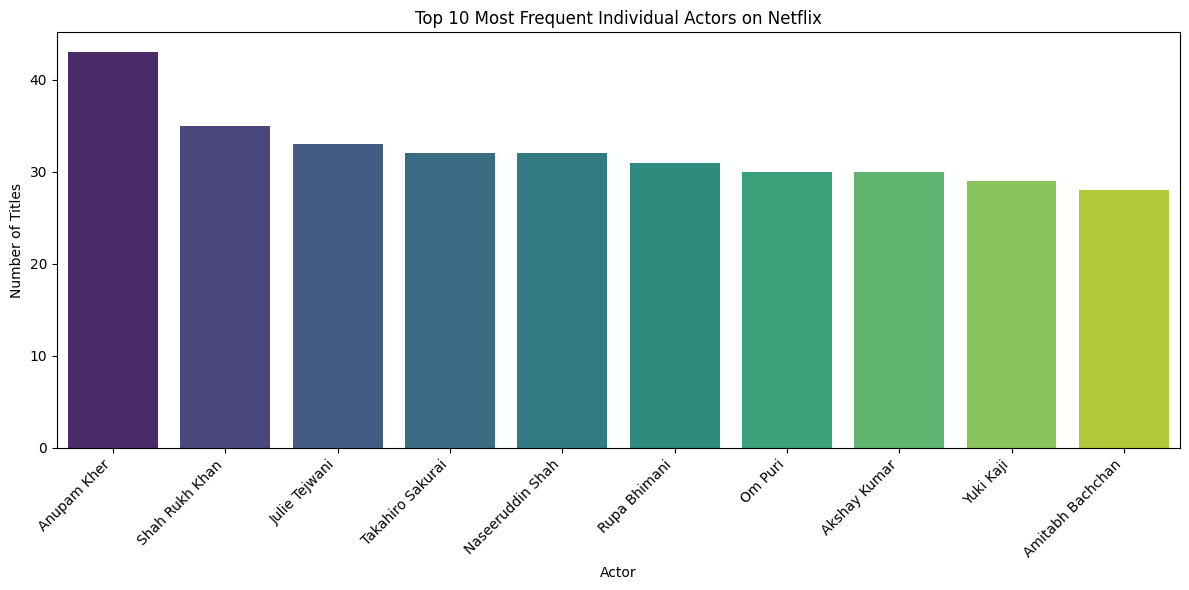

In [82]:
all_actors = df[df['cast'] != 'Unknown']['cast'].str.split(', ').explode()

top_actors = all_actors.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_actors.index, y=top_actors.values, palette='viridis')
plt.xlabel('Actor')
plt.ylabel('Number of Titles')
plt.title('Top 10 Most Frequent Individual Actors on Netflix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Visualization 3:  Movies vs TV Shows Distribution(Histogram)

/tmp/ipykernel_5700/2089779847.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='viridis')


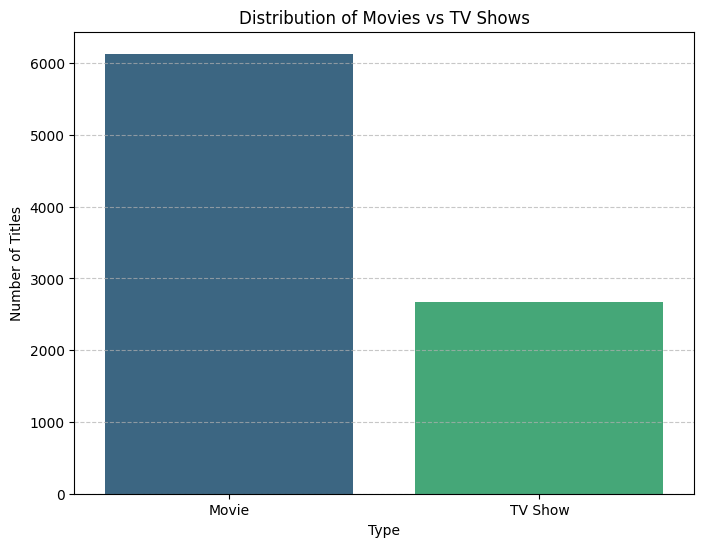

In [77]:
plt.figure(figsize=(8, 6))
plt.hist(df["type"])
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.title("Distribution of Movies vs TV Shows")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

A histogram is generally used for continuous data. For categorical data like 'type', a bar plot is more appropriate to show the count of each category. Here's how to create a bar plot using `seaborn.countplot`:

Visualization 4: Distribution of Release years(Pie Chart)

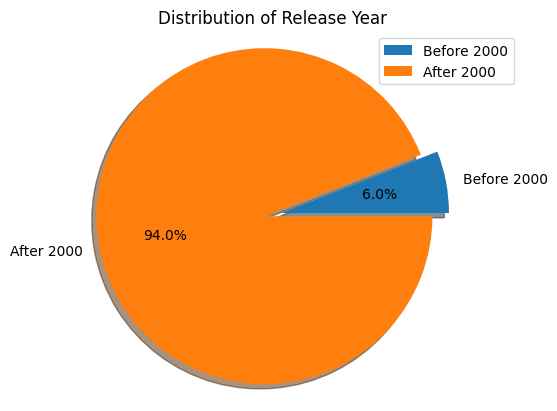

In [65]:
before_2000 = df[df["release_year"] < 2000]["release_year"].count()
after_2000 = df[df["release_year"] >= 2000]["release_year"].count()
plt.pie([before_2000, after_2000], labels=["Before 2000", "After 2000"], autopct="%1.1f%%", explode=[0, 0.1], shadow=True)
plt.title("Distribution of Release Year")
plt.legend(["Before 2000", "After 2000"])
plt.axis("equal")
plt.show()

Visualization 5:  Distribution of Release Years (Heap Map)

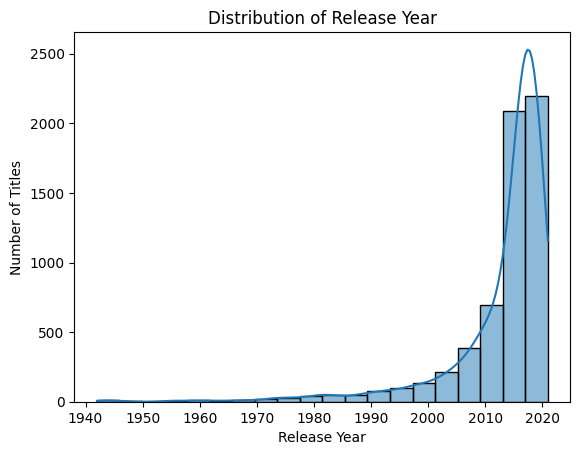

In [69]:
movie_df = df[df["type"] == "Movie"].copy()

movie_df = movie_df[movie_df["duration"] != "Unknown"]

movie_df["duration_cleaned"] = movie_df["duration"].str.replace("min", "", regex=False).str.strip()

movie_df["duration_num"] = pd.to_numeric(movie_df["duration_cleaned"], errors='coerce')

movie_df = movie_df.dropna(subset=["duration_num"])

movie_df["duration_num"] = movie_df["duration_num"].astype(int)

sns.histplot(movie_df["release_year"], bins=20, kde=True)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.title("Distribution of Release Year")
plt.show()

Visualization 6: Correlation Between Numeric Variables (Box Plot)

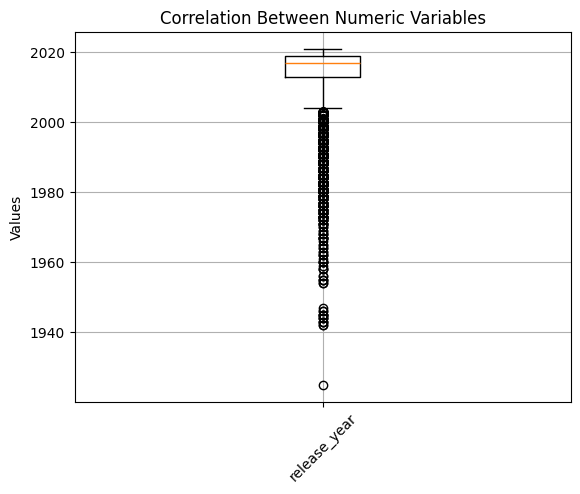

In [66]:
numeric_df = df.select_dtypes(include="number")
plt.boxplot(numeric_df.values)
plt.xticks(range(1, len(numeric_df.columns) + 1), numeric_df.columns, rotation=45)
plt.ylabel("Values")
plt.title("Correlation Between Numeric Variables")
plt.grid()
plt.show()

Visualization 7: Relationship Between Release Year and Duration(Scatter Plot)

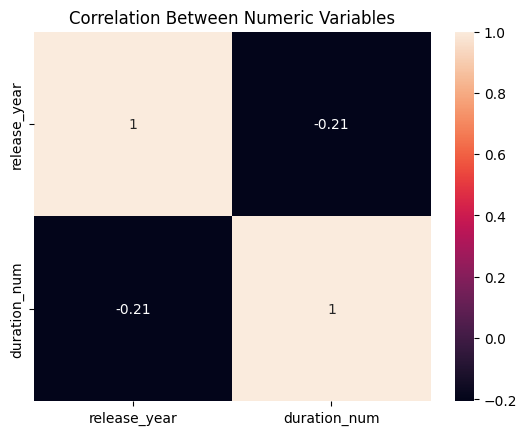

In [73]:
movie_df=df[df["type"]=="Movie"].copy()
movie_df = movie_df[movie_df["duration"]!="Unknown"]

movie_df["duration_cleaned"] = movie_df["duration"].str.replace("min", "", regex=False).str.strip()

movie_df["duration_num"] = pd.to_numeric(movie_df["duration_cleaned"], errors='coerce')

movie_df = movie_df.dropna(subset=["duration_num"])

movie_df["duration_num"] = movie_df["duration_num"].astype(int)
sns.heatmap(movie_df[["release_year","duration_num"]].corr(),annot=True)
plt.title("Correlation Between Numeric Variables")
plt.show()

Visualization 8: Relationship Between Release Year and Duration(Bubble Plot)

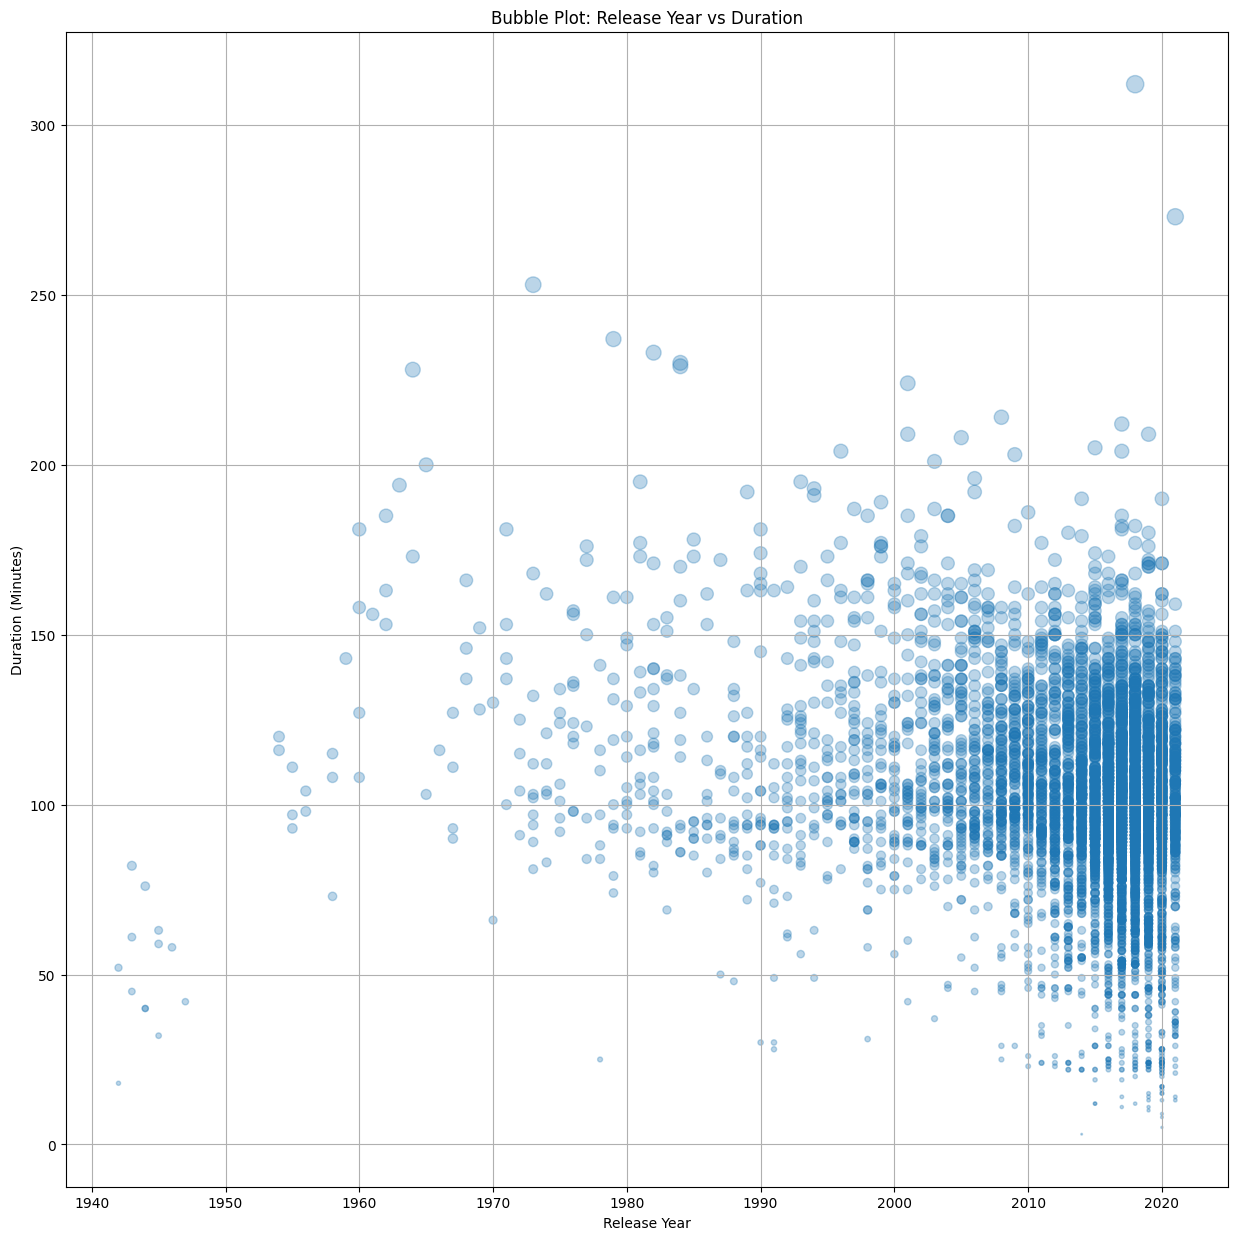

In [76]:
movie_df = df[df["type"]=="Movie"].copy()

movie_df["duration_cleaned"] = movie_df["duration"].str.replace(" min", "", regex=False).str.strip()

movie_df["duration_num"] = pd.to_numeric(movie_df["duration_cleaned"], errors='coerce')

movie_df = movie_df.dropna(subset=["duration_num"])

movie_df["duration_num"] = movie_df["duration_num"].astype(int)

plt.figure(figsize=(15,15))
plt.scatter(movie_df["release_year"],movie_df["duration_num"],s=movie_df["duration_num"]*0.5,alpha=0.3)

plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")
plt.title("Bubble Plot: Release Year vs Duration")
plt.grid()
plt.show()

Step 4 Summary – Visualizations

1. A total of 8 visualizations were developed to gain a deeper understanding of the Netflix dataset and uncover key trends, patterns, and relationships embedded within the data.

2. Through the bar chart, the top countries producing the greatest number of Netflix titles were revealed, with the United States standing out as the dominant contributor.

3. Both the line chart and histogram focused on the analysis of release years, collectively demonstrating that Netflix content output grew substantially in more recent years.
4. The scatter plot and bubble plot were employed to examine the relationship between release year and movie duration, offering a clearer picture of how movie lengths are spread across different time periods.

5. The pie chart illustrated the proportion of Movies versus TV Shows available on Netflix, confirming that Movies account for the larger share of the platform's content.

6. The heatmap was instrumental in detecting correlations among numeric variables, while the boxplot provided insight into the spread of release years and brought attention to the presence of outliers.

7. Taken together, the visualizations successfully converted raw data into actionable insights, making it considerably easier to interpret the underlying structure and trends found within the Netflix dataset.

Here's the rewritten version:
Step 5 – Insights Report

1. Movies dominate the Netflix catalog: As reflected in the Pie Chart illustrating Movies vs TV Shows Distribution, Movies constitute approximately 69.6% of the total content, while TV Shows represent only 30.4%. This clearly suggests that Netflix places a stronger emphasis on movies over television series.

2. The United States contributes the highest number of Netflix titles: As evident from the Bar Chart depicting the Top 10 Countries by Number of Netflix Titles, the United States leads by a considerable margin, far surpassing all other countries. This highlights the heavy concentration of Netflix content originating from the U.S. market.

3.Netflix content has grown rapidly in recent years: Both the Line Chart and Histogram of Release Years reveal a dramatic surge in the number of titles released post-2000, with the growth becoming especially pronounced after 2010. This reflects a significant acceleration in content production and acquisition over time.
4. A substantial portion of Netflix titles were released after 2020: Findings from the filtering analysis indicate that 592 titles were added after 2020, demonstrating Netflix's ongoing commitment to continuously refreshing its library with the most current content available.
5. The majority of Netflix content was released between 2013 and 2019: As illustrated by the Boxplot of Release Years, most titles fall within this timeframe, with earlier releases appearing as outliers. This pattern suggests that Netflix tends to prioritize relatively recent content over older productions.

Short Note:

One of the most unexpected discoveries was the notably higher proportion of Movies compared to TV Shows on Netflix, with Movies comprising close to 70% of the platform's entire content library.

An equally noteworthy observation was the sharp and rapid rise in the number of titles following 2010, reflecting a period of aggressive content expansion.

It was further surprising to find that the United States contributes a vastly greater number of Netflix titles than any other country represented in the dataset.

Collectively, these findings highlight just how heavily Netflix's content is skewed toward particular categories and specific geographic regions.